# Grid Network Analysis

## Quick Summary

- Current grid profile: `rural1_phase1`, SimBench network `1-LV-rural1--0-sw`.
- Static network size: `15` buses, `13` lines, `1` transformer, slack bus at `42`, agent buses at `[10, 6, 12]`.
- Transformer nameplate: `0.16 MVA = 160 kVA`, `20/0.4 kV`, environment loading limit `100%`.
- Line type: all lines are `NAYY 4x150SE 0.6/1kV`, each with `max_i_ka = 0.27`; at `0.4 kV` this is about `187 kVA` apparent-power capacity per line (rough estimate from voltage and current limit).
- Native full-network 15-minute total load is usually in the tens of kW: mean `22.72 kW`, median `22.01 kW`, P10-P90 about `12.05-34.53 kW`, yearly max `74.37 kW` at `2016-01-01 12:30:00`.
- Native full-network 15-minute total PV is highly seasonal and daytime-driven: mean `11.85 kW`, median `0.00 kW`, yearly max `92.44 kW` at `2016-05-26 13:00:00`.
- In the project 3-agent dataset, the three selected agents together are often net exporters because the selected buses are PV-heavy: 15-minute total agent net load has mean `-8.92 kW`, median `0.65 kW`, P10-P90 about `-36.61 to 2.18 kW`, and yearly minimum `-80.59 kW` at `2016-05-26 13:00:00`.
- If we express agent-side base injection as positive = exporting to the grid, the typical per-bus magnitudes are:
  bus `10`: median `-0.07 kW`, P90 `20.43 kW`, max `45.94 kW`;
  bus `6`: median `-0.51 kW`, P90 `10.25 kW`, max `23.28 kW`;
  bus `12`: median `-0.05 kW`, P90 `6.35 kW`, max `13.77 kW`.
- The runtime battery action limit in the current environment is only `+-2.5 kW` per agent, or `+-7.5 kW` total if all three move in the same direction. This is much smaller than the PV-driven midday export peaks on the selected buses, which is why battery actions can look visually modest unless they are scaled up.

This notebook explains the current `rural1_phase1` grid from both the native SimBench perspective and the current project environment perspective.

It covers:

1. Static grid assets: buses, lines, transformer, slack bus, PV buses, and agent buses.
2. Yearly data coverage and extrema for the full native network and the 3-agent project dataset.
3. Representative native-network operating snapshots and seasonal typical-day voltage behavior.
4. Agent-aware snapshots under the current project environment approximation.

The seasonal 3D voltage figure uses the same voltage-axis limits across all four subplots so day-to-day comparison is visually fair.


In [1]:
from pathlib import Path
import json
import math
import os
import sys
import warnings

os.environ.setdefault("NUMBA_DISABLE_JIT", "1")

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / "configs").exists():
    project_root = project_root.parent
if not (project_root / "configs").exists():
    raise RuntimeError("Could not locate the project root from the notebook working directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pandapower as pp
from IPython.display import display

from configs import compose_experiment_config
from data.loaders.simbench_export import build_simbench_absolute_frame
from envs.grid.core.net_builder import apply_bus_injections, build_simbench_net, set_timeseries_profiles

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.

In [2]:
cfg = compose_experiment_config(
     profile="debug",
     algorithm="MADDPG",
     observation_profile="simbench",
     forecast_type="perfect",
     data_dir=project_root / "data",
     runtime_mode="performance",
     seed=0,
     require_cuda=False,
 )
  
 agent_bus_ids = list(map(int, cfg.grid.agent_bus_ids))
 metadata_path = project_root / "data" / "simbench_2016_metadata.json"
 metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
 
 raw_net = build_simbench_net(cfg.grid.sb_code)
 native_year_df, native_load_buses, native_pv_buses, native_prosumers = build_simbench_absolute_frame(raw_net)
 native_year_df["timestamp"] = pd.to_datetime(native_year_df["timestamp"])
 native_year_df["total_net_kw"] = native_year_df["total_load_kw"] - native_year_df["total_pv_kw"]
 
 project_year_df = pd.read_csv(project_root / "data" / "simbench_2016_full.csv", parse_dates=["timestamp"])
 project_load_cols = [col for col in project_year_df.columns if col.startswith("load")]
 project_pv_cols = [col for col in project_year_df.columns if col.startswith("pv")]
 project_year_df["agent_total_load_kw"] = project_year_df[project_load_cols].sum(axis=1)
 project_year_df["agent_total_pv_kw"] = project_year_df[project_pv_cols].sum(axis=1)
 project_year_df["agent_total_net_kw"] = project_year_df["agent_total_load_kw"] - project_year_df["agent_total_pv_kw"]
 
 runtime_summary = pd.Series(
     {
         "project_root": str(project_root),
         "simbench_code": cfg.grid.sb_code,
         "agent_bus_ids": agent_bus_ids,
         "native_bus_count": int(len(raw_net.bus)),
         "native_line_count": int(len(raw_net.line)),
         "native_trafo_count": int(len(raw_net.trafo)),
         "native_load_bus_count": len(native_load_buses),
         "native_pv_bus_count": len(native_pv_buses),
         "native_year_rows": int(len(native_year_df)),
         "project_agent_dataset_rows": int(len(project_year_df)),
         "native_time_start": str(native_year_df["timestamp"].min()),
         "native_time_end": str(native_year_df["timestamp"].max()),
         "project_time_start": str(project_year_df["timestamp"].min()),
         "project_time_end": str(project_year_df["timestamp"].max()),
         "dt_hours": float(cfg.env.dt),
         "runtime_battery_capacity_kwh_each": float(cfg.env.battery_capacity),
         "runtime_battery_max_charge_discharge_kw_each": float(cfg.env.max_charge_rate),
     }
 )
 display(runtime_summary)


project_root                                    D:\GithubProject\MADRL_ESS
simbench_code                                            1-LV-rural1--0-sw
agent_bus_ids                                                  [10, 6, 12]
native_bus_count                                                        15
native_line_count                                                       13
native_trafo_count                                                       1
native_load_bus_count                                                   13
native_pv_bus_count                                                      4
native_year_rows                                                     35136
project_agent_dataset_rows                                           35136
native_time_start                                      2016-01-01 00:00:00
native_time_end                                        2016-12-31 23:45:00
project_time_start                                     2016-01-01 00:00:00
project_time_end         

In [3]:
def runpp_with_fallback(net, pf_solver="nr"):
    attempts = [
        {
            "algorithm": pf_solver,
            "numba": False,
            "lightsim2grid": False,
            "calculate_voltage_angles": False,
            "voltage_depend_loads": False,
            "init": "flat",
        },
        {
            "algorithm": "bfsw",
            "numba": False,
            "lightsim2grid": False,
            "calculate_voltage_angles": False,
            "voltage_depend_loads": False,
            "init": "flat",
        },
        {
            "algorithm": pf_solver,
            "numba": False,
            "lightsim2grid": False,
            "calculate_voltage_angles": False,
            "voltage_depend_loads": False,
            "init": "auto",
        },
    ]
    errors = []
    for attempt in attempts:
        try:
            pp.runpp(net, verbose=False, **attempt)
            return True, ""
        except TypeError:
            fallback = dict(attempt)
            fallback.pop("lightsim2grid", None)
            try:
                pp.runpp(net, verbose=False, **fallback)
                return True, ""
            except Exception as inner_exc:
                errors.append(f"{fallback} -> {type(inner_exc).__name__}: {inner_exc}")
        except Exception as exc:
            errors.append(f"{attempt} -> {type(exc).__name__}: {exc}")
    return False, " | ".join(errors) if errors else "runpp failed"


def get_bus_positions(net):
    if (
        hasattr(net, "bus_geodata")
        and len(net.bus_geodata) > 0
        and {"x", "y"}.issubset(net.bus_geodata.columns)
    ):
        geodata = net.bus_geodata.reindex(net.bus.index)
        if geodata[["x", "y"]].notna().all().all():
            return {
                int(bus): (float(geodata.at[bus, "x"]), float(geodata.at[bus, "y"]))
                for bus in net.bus.index
            }
    graph = nx.Graph()
    graph.add_nodes_from(int(bus) for bus in net.bus.index)
    for row in net.line.itertuples():
        graph.add_edge(int(row.from_bus), int(row.to_bus))
    for row in net.trafo.itertuples():
        graph.add_edge(int(row.hv_bus), int(row.lv_bus))
    bus_switches = net.switch[net.switch["et"] == "b"] if len(net.switch) else net.switch
    for row in bus_switches.itertuples():
        graph.add_edge(int(row.bus), int(row.element))
    return nx.spring_layout(graph, seed=0)


def topology_edges(net):
    edges = []
    for row in net.line.itertuples():
        edges.append((int(row.from_bus), int(row.to_bus), "line"))
    for row in net.trafo.itertuples():
        edges.append((int(row.hv_bus), int(row.lv_bus), "trafo"))
    if len(net.switch):
        for row in net.switch[net.switch["et"] == "b"].itertuples():
            edges.append((int(row.bus), int(row.element), "switch"))
    return edges


def plot_topology(net, agent_buses, title):
    positions = get_bus_positions(net)
    agent_buses = set(map(int, agent_buses))
    all_buses = set(map(int, net.bus.index))
    ext_buses = set(map(int, net.ext_grid["bus"].tolist()))
    load_buses = set(map(int, net.load["bus"].tolist()))
    sgen_buses = set(map(int, net.sgen["bus"].tolist()))
    consumer_buses = load_buses - agent_buses
    pv_only_buses = (sgen_buses - load_buses) - agent_buses
    other_buses = all_buses - agent_buses - consumer_buses - pv_only_buses - ext_buses
    fig, ax = plt.subplots(figsize=(10, 6))
    for from_bus, to_bus, edge_kind in topology_edges(net):
        x1, y1 = positions[int(from_bus)]
        x2, y2 = positions[int(to_bus)]
        style = "--" if edge_kind == "switch" else "-"
        width = 1.8 if edge_kind == "trafo" else 1.0
        ax.plot([x1, x2], [y1, y2], color="0.75", linewidth=width, linestyle=style, zorder=1)
    categories = [
        ("Agent bus", agent_buses, "#d95f02", 120),
        ("Load bus", consumer_buses, "#1f78b4", 85),
        ("PV-only bus", pv_only_buses, "#33a02c", 85),
        ("Slack/ext grid", ext_buses, "#e31a1c", 140),
        ("Other bus", other_buses, "#bdbdbd", 55),
    ]
    for label, buses, color, size in categories:
        buses = sorted(buses)
        if not buses:
            continue
        ax.scatter(
            [positions[bus][0] for bus in buses],
            [positions[bus][1] for bus in buses],
            s=size,
            c=color,
            label=label,
            edgecolors="black",
            linewidths=0.5,
            zorder=3,
        )
    for bus, (x, y) in positions.items():
        ax.text(x, y + 0.01, str(bus), fontsize=8, ha="center", va="bottom")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(loc="upper left")
    ax.set_aspect("equal")
    plt.show()


def build_static_tables(net, agent_buses):
    slack_buses = set(net.ext_grid["bus"].astype(int).tolist())
    load_buses = set(net.load["bus"].astype(int).tolist())
    pv_buses = set(net.sgen["bus"].astype(int).tolist())
    agent_buses = set(map(int, agent_buses))
    bus_table = net.bus.reset_index(names="bus_id").copy()
    bus_table["is_slack"] = bus_table["bus_id"].isin(slack_buses)
    bus_table["has_load"] = bus_table["bus_id"].isin(load_buses)
    bus_table["has_pv"] = bus_table["bus_id"].isin(pv_buses)
    bus_table["is_agent_bus"] = bus_table["bus_id"].isin(agent_buses)
    bus_table["category"] = np.select(
        [
            bus_table["is_slack"],
            bus_table["is_agent_bus"],
            bus_table["has_load"] & bus_table["has_pv"],
            bus_table["has_load"],
            bus_table["has_pv"],
        ],
        ["slack", "agent", "prosumer", "load", "pv"],
        default="other",
    )
    line_table = net.line.reset_index(names="line_id").copy()
    line_table["from_vn_kv"] = line_table["from_bus"].map(net.bus["vn_kv"])
    line_table["to_vn_kv"] = line_table["to_bus"].map(net.bus["vn_kv"])
    line_table["approx_voltage_kv"] = line_table[["from_vn_kv", "to_vn_kv"]].min(axis=1)
    line_table["approx_thermal_capacity_kva"] = (
        np.sqrt(3.0) * line_table["approx_voltage_kv"] * line_table["max_i_ka"] * 1000.0
    )
    trafo_table = net.trafo.reset_index(names="trafo_id").copy()
    trafo_table["rated_kva"] = trafo_table["sn_mva"] * 1000.0
    static_summary = pd.Series(
        {
            "bus_count": int(len(bus_table)),
            "line_count": int(len(line_table)),
            "trafo_count": int(len(trafo_table)),
            "slack_bus_ids": sorted(slack_buses),
            "load_bus_ids": sorted(load_buses),
            "pv_bus_ids": sorted(pv_buses),
            "agent_bus_ids": sorted(agent_buses),
            "static_nominal_load_kw_sum": float(net.load["p_mw"].sum() * 1000.0),
            "static_nominal_pv_kw_sum": float(net.sgen["p_mw"].sum() * 1000.0),
            "trafo_rated_kva_sum": float(trafo_table["rated_kva"].sum()),
            "line_approx_thermal_capacity_kva_min": float(line_table["approx_thermal_capacity_kva"].min()),
            "line_approx_thermal_capacity_kva_max": float(line_table["approx_thermal_capacity_kva"].max()),
            "voltage_limit_min_pu": float(cfg.grid.v_min_pu),
            "voltage_limit_max_pu": float(cfg.grid.v_max_pu),
            "line_loading_limit_pct": float(cfg.grid.line_max_loading_pct),
        }
    )
    return static_summary, bus_table, line_table, trafo_table


In [4]:
def native_row_to_bus_maps(row):
    load_map = {bus: float(row[f"load_bus_{bus}"]) for bus in native_load_buses}
    pv_map = {bus: float(row[f"pv_bus_{bus}"]) for bus in native_pv_buses}
    return load_map, pv_map


def aggregate_bus_elements(net, res_bus_vm):
    bus_ids = pd.Index(net.bus.index.astype(int), name="bus_id")
    load_kw = (net.load.groupby("bus")["p_mw"].sum() * 1000.0).reindex(bus_ids, fill_value=0.0) if len(net.load) else pd.Series(0.0, index=bus_ids)
    sgen_kw = (net.sgen.groupby("bus")["p_mw"].sum() * 1000.0).reindex(bus_ids, fill_value=0.0) if len(net.sgen) else pd.Series(0.0, index=bus_ids)
    ext_grid_kw = pd.Series(0.0, index=bus_ids)
    if len(net.ext_grid) and len(net.res_ext_grid):
        ext_df = pd.DataFrame(
            {
                "bus": net.ext_grid["bus"].astype(int).to_numpy(),
                "p_kw": net.res_ext_grid["p_mw"].astype(float).to_numpy() * 1000.0,
            }
        )
        ext_grid_kw = ext_df.groupby("bus")["p_kw"].sum().reindex(bus_ids, fill_value=0.0)
    bus_df = pd.DataFrame(
        {
            "bus_id": bus_ids.astype(int),
            "is_agent_bus": [int(bus) in set(agent_bus_ids) for bus in bus_ids],
            "load_kw": load_kw.to_numpy(),
            "sgen_kw": sgen_kw.to_numpy(),
            "specified_net_injection_kw": (sgen_kw - load_kw).to_numpy(),
            "slack_ext_grid_kw": ext_grid_kw.to_numpy(),
            "total_bus_injection_kw": (sgen_kw - load_kw + ext_grid_kw).to_numpy(),
            "vm_pu": res_bus_vm,
        }
    )
    return bus_df


def extract_network_state(net, label, timestamp, extra=None):
    bus_df = aggregate_bus_elements(net, net.res_bus["vm_pu"].to_numpy(dtype=float))
    line_cols = ["from_bus", "to_bus", "length_km", "std_type", "max_i_ka", "max_loading_percent"]
    line_df = net.line.loc[:, line_cols].reset_index(names="line_id").copy()
    if len(net.line):
        line_df["loading_percent"] = net.res_line["loading_percent"].to_numpy(dtype=float)
        line_df["p_from_mw"] = net.res_line["p_from_mw"].to_numpy(dtype=float)
    trafo_cols = ["hv_bus", "lv_bus", "std_type", "sn_mva", "vn_hv_kv", "vn_lv_kv", "max_loading_percent"]
    trafo_df = net.trafo.loc[:, trafo_cols].reset_index(names="trafo_id").copy()
    if len(net.trafo):
        trafo_df["loading_percent"] = net.res_trafo["loading_percent"].to_numpy(dtype=float)
        trafo_df["p_hv_mw"] = net.res_trafo["p_hv_mw"].to_numpy(dtype=float)
    slack_p_mw = float(net.res_ext_grid["p_mw"].sum()) if len(net.ext_grid) and len(net.res_ext_grid) else 0.0
    state = {
        "label": label,
        "timestamp": pd.Timestamp(timestamp),
        "bus_df": bus_df,
        "line_df": line_df,
        "trafo_df": trafo_df,
        "slack_p_mw": slack_p_mw,
    }
    if extra:
        state.update(extra)
    return state


def run_native_snapshot(row, label):
    net = build_simbench_net(cfg.grid.sb_code)
    load_map, pv_map = native_row_to_bus_maps(row)
    set_timeseries_profiles(net, load_map, pv_map)
    ok, error = runpp_with_fallback(net, cfg.grid.pf_solver)
    if not ok:
        raise RuntimeError(f"Native snapshot failed at {row['timestamp']}: {error}")
    return extract_network_state(net, label, row["timestamp"])


def project_row_to_agent_vectors(row):
    load = np.array([float(row[f"load{i + 1}"]) for i in range(len(agent_bus_ids))], dtype=float)
    pv = np.array([float(row[f"pv{i + 1}"]) for i in range(len(agent_bus_ids))], dtype=float)
    net_load = load - pv
    return load, pv, net_load


def run_project_env_snapshot(row, batt_kw=None, label="project_env"):
    if batt_kw is None:
        batt_kw = np.zeros(len(agent_bus_ids), dtype=float)
    load_kw, pv_kw, base_net_load_kw = project_row_to_agent_vectors(row)
    net = build_simbench_net(cfg.grid.sb_code)
    bus_injection_map = {
        int(agent_bus_ids[i]): float(-(base_net_load_kw[i] + batt_kw[i]))
        for i in range(len(agent_bus_ids))
    }
    apply_bus_injections(net, bus_injection_map)
    ok, error = runpp_with_fallback(net, cfg.grid.pf_solver)
    if not ok:
        raise RuntimeError(f"Project-env snapshot failed at {row['timestamp']}: {error}")
    return extract_network_state(
        net,
        label,
        row["timestamp"],
        extra={
            "agent_load_kw": load_kw,
            "agent_pv_kw": pv_kw,
            "agent_base_net_load_kw": base_net_load_kw,
            "agent_batt_kw": np.asarray(batt_kw, dtype=float),
            "agent_bus_injection_map_kw": bus_injection_map,
        },
    )


def summarize_snapshot(state):
    bus_df = state["bus_df"]
    line_df = state["line_df"]
    trafo_df = state["trafo_df"]
    max_line_idx = int(line_df["loading_percent"].idxmax()) if len(line_df) else -1
    max_trafo_idx = int(trafo_df["loading_percent"].idxmax()) if len(trafo_df) else -1
    return {
        "label": state["label"],
        "timestamp": state["timestamp"],
        "vm_min": float(bus_df["vm_pu"].min()),
        "vm_min_bus": int(bus_df.loc[bus_df["vm_pu"].idxmin(), "bus_id"]),
        "vm_max": float(bus_df["vm_pu"].max()),
        "vm_max_bus": int(bus_df.loc[bus_df["vm_pu"].idxmax(), "bus_id"]),
        "max_line_loading_pct": float(line_df["loading_percent"].max()) if len(line_df) else np.nan,
        "max_line_id": int(line_df.loc[max_line_idx, "line_id"]) if len(line_df) else np.nan,
        "max_trafo_loading_pct": float(trafo_df["loading_percent"].max()) if len(trafo_df) else np.nan,
        "max_trafo_id": int(trafo_df.loc[max_trafo_idx, "trafo_id"]) if len(trafo_df) else np.nan,
        "slack_p_mw": float(state["slack_p_mw"]),
    }


def extrema_summary(df, column, label):
    idx_max = int(df[column].idxmax())
    idx_min = int(df[column].idxmin())
    return {
        "series": label,
        "max_value": float(df.loc[idx_max, column]),
        "max_time": pd.Timestamp(df.loc[idx_max, "timestamp"]),
        "min_value": float(df.loc[idx_min, column]),
        "min_time": pd.Timestamp(df.loc[idx_min, "timestamp"]),
    }


def season_name(ts):
    month = int(pd.Timestamp(ts).month)
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Spring"
    if month in (6, 7, 8):
        return "Summer"
    return "Autumn"


def select_typical_days(native_df):
    daily = native_df.copy()
    daily["date"] = daily["timestamp"].dt.floor("D")
    daily["season"] = daily["timestamp"].map(season_name)
    daily_stats = (
        daily.groupby(["season", "date"], as_index=False)
        .agg(
            day_load_mwh=("total_load_kw", lambda s: float(s.sum() * cfg.env.dt / 1000.0)),
            day_pv_mwh=("total_pv_kw", lambda s: float(s.sum() * cfg.env.dt / 1000.0)),
            day_mean_net_kw=("total_net_kw", "mean"),
            day_peak_net_kw=("total_net_kw", "max"),
            day_min_net_kw=("total_net_kw", "min"),
        )
    )
    season_order = ["Winter", "Spring", "Summer", "Autumn"]
    picked_rows = []
    for season in season_order:
        season_slice = daily_stats.loc[daily_stats["season"] == season].copy()
        target = float(season_slice["day_mean_net_kw"].median())
        season_slice["median_distance"] = (season_slice["day_mean_net_kw"] - target).abs()
        picked_rows.append(season_slice.sort_values(["median_distance", "date"]).iloc[0])
    return daily_stats, pd.DataFrame(picked_rows).reset_index(drop=True)


def simulate_native_day(day_timestamp):
    day = pd.Timestamp(day_timestamp).floor("D")
    day_rows = native_year_df.loc[native_year_df["timestamp"].dt.floor("D") == day].copy()
    day_rows = day_rows.sort_values("timestamp").reset_index(drop=True)
    bus_ids = np.array(sorted(map(int, raw_net.bus.index)), dtype=int)
    voltage_rows = []
    max_line_loading_pct = -np.inf
    max_trafo_loading_pct = -np.inf
    for _, row in day_rows.iterrows():
        state = run_native_snapshot(row, label=f"native_{day.date()}")
        voltage_rows.append(state["bus_df"].sort_values("bus_id")["vm_pu"].to_numpy(dtype=float))
        max_line_loading_pct = max(max_line_loading_pct, float(state["line_df"]["loading_percent"].max()))
        if len(state["trafo_df"]):
            max_trafo_loading_pct = max(max_trafo_loading_pct, float(state["trafo_df"]["loading_percent"].max()))
    voltage_matrix = np.vstack(voltage_rows)
    hours = ((day_rows["timestamp"] - day) / pd.Timedelta(hours=1)).to_numpy(dtype=float)
    return {
        "date": day,
        "timestamps": day_rows["timestamp"].copy(),
        "hours": hours,
        "bus_ids": bus_ids,
        "voltage_matrix": voltage_matrix,
        "vm_min": float(voltage_matrix.min()),
        "vm_max": float(voltage_matrix.max()),
        "max_line_loading_pct": float(max_line_loading_pct),
        "max_trafo_loading_pct": float(max_trafo_loading_pct),
    }


def plot_seasonal_voltage_surfaces(day_results, title_prefix):
    season_order = ["Winter", "Spring", "Summer", "Autumn"]
    all_vm = np.concatenate([day_results[season]["voltage_matrix"].ravel() for season in season_order])
    z_min = min(float(cfg.grid.v_min_pu), float(all_vm.min())) - 0.005
    z_max = max(float(cfg.grid.v_max_pu), float(all_vm.max())) + 0.005
    fig = plt.figure(figsize=(16, 12))
    surf = None
    for idx, season in enumerate(season_order, start=1):
        result = day_results[season]
        ax = fig.add_subplot(2, 2, idx, projection="3d")
        x = np.arange(len(result["bus_ids"]), dtype=float)
        y = result["hours"]
        X, Y = np.meshgrid(x, y)
        Z = result["voltage_matrix"]
        surf = ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0.0, antialiased=True)
        ax.plot_wireframe(X, Y, np.full_like(Z, cfg.grid.v_min_pu), color="red", linewidth=0.2, alpha=0.12)
        ax.plot_wireframe(X, Y, np.full_like(Z, cfg.grid.v_max_pu), color="red", linewidth=0.2, alpha=0.12)
        ax.set_xticks(x)
        ax.set_xticklabels(result["bus_ids"], rotation=0, fontsize=8)
        ax.set_xlabel("Bus id")
        ax.set_ylabel("Hour")
        ax.set_zlabel("Voltage (pu)")
        ax.set_zlim(z_min, z_max)
        ax.set_title(f"{season}: {result['date'].date()}\nVm in [{result['vm_min']:.4f}, {result['vm_max']:.4f}] pu")
        ax.view_init(elev=28, azim=-125)
    fig.suptitle(title_prefix, fontsize=16)
    if surf is not None:
        fig.colorbar(surf, ax=fig.axes, shrink=0.65, pad=0.08, label="Voltage (pu)")
    plt.tight_layout()
    plt.show()


bus_count                                                                        15
line_count                                                                       13
trafo_count                                                                       1
slack_bus_ids                                                                  [42]
load_bus_ids                            [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
pv_bus_ids                                                           [6, 7, 10, 12]
agent_bus_ids                                                           [6, 10, 12]
static_nominal_load_kw_sum                                                     80.0
static_nominal_pv_kw_sum                                                    160.381
trafo_rated_kva_sum                                                           160.0
line_approx_thermal_capacity_kva_min                                     187.061487
line_approx_thermal_capacity_kva_max                                     187

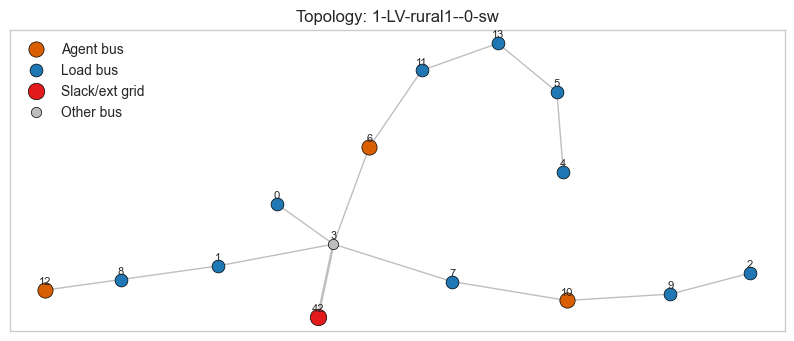

,bus_id,name,vn_kv,type,category,has_load,has_pv,is_agent_bus,is_slack
0,0,LV1.101 Bus 1,0.4,b,load,True,False,False,False
1,1,LV1.101 Bus 2,0.4,b,load,True,False,False,False
2,2,LV1.101 Bus 3,0.4,b,load,True,False,False,False
3,3,LV1.101 Bus 4,0.4,b,other,False,False,False,False
4,4,LV1.101 Bus 5,0.4,b,load,True,False,False,False
5,5,LV1.101 Bus 6,0.4,b,load,True,False,False,False
6,6,LV1.101 Bus 7,0.4,b,agent,True,True,True,False
7,7,LV1.101 Bus 8,0.4,b,prosumer,True,True,False,False
8,8,LV1.101 Bus 9,0.4,b,load,True,False,False,False
9,9,LV1.101 Bus 10,0.4,b,load,True,False,False,False


,line_id,from_bus,to_bus,length_km,std_type,max_i_ka,max_loading_percent,approx_thermal_capacity_kva
0,0,9,2,0.055767,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
1,1,13,11,0.053576,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
2,2,6,3,0.049814,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
3,3,8,1,0.017886,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
4,4,7,10,0.016089,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
5,5,10,9,0.024766,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
6,6,3,7,0.005141,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
7,7,11,6,0.002147,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
8,8,5,13,0.137215,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487
9,9,3,0,0.132499,NAYY 4x150SE 0.6/1kV,0.27,100.0,187.061487


,trafo_id,hv_bus,lv_bus,std_type,rated_kva,vn_hv_kv,vn_lv_kv,vk_percent,tap_side,tap_min,tap_max,tap_step_percent,max_loading_percent
0,0,42,3,0.16 MVA 20/0.4 kV DOTE 160/20 SGB,160.0,20.0,0.4,4.0,hv,-2.0,2.0,2.5,100.0


,series,max_value,max_time,min_value,min_time
0,Native full-network total load (kW),74.368492,2016-01-01 12:30:00,6.862547,2016-08-28 06:00:00
1,Native full-network total PV (kW),92.437469,2016-05-26 13:00:00,0.000000,2016-01-01 00:00:00
2,Native full-network total net load (kW),74.368492,2016-01-01 12:30:00,-69.438416,2016-07-27 13:15:00


,series,max_value,max_time,min_value,min_time
0,Project 3-agent total load (kW),5.158883,2016-12-25 10:45:00,0.397067,2016-07-20 05:00:00
1,Project 3-agent total PV (kW),82.084295,2016-05-26 13:00:00,0.000000,2016-01-01 00:00:00
2,Project 3-agent total net load (kW),4.637406,2016-12-24 12:00:00,-80.586953,2016-05-26 13:00:00


,bus_id,peak_load_kw,peak_time
0,0,14.0,2016-01-01 12:30:00
3,4,14.0,2016-01-01 12:30:00
10,11,12.0,2016-01-01 12:30:00
2,2,8.0,2016-01-01 12:30:00
8,9,6.0,2016-01-01 12:30:00
12,13,5.0,2016-01-01 12:30:00
1,1,4.0,2016-01-01 12:30:00
7,8,4.0,2016-01-01 12:30:00
4,5,3.0,2016-01-01 12:30:00
5,6,3.0,2016-01-01 12:30:00


,bus_id,peak_pv_kw,peak_time
2,10,46.102448,2016-05-26 14:00:00
0,6,24.105246,2016-05-24 12:00:00
3,12,13.860517,2016-05-24 12:00:00
1,7,11.310618,2016-05-24 11:00:00


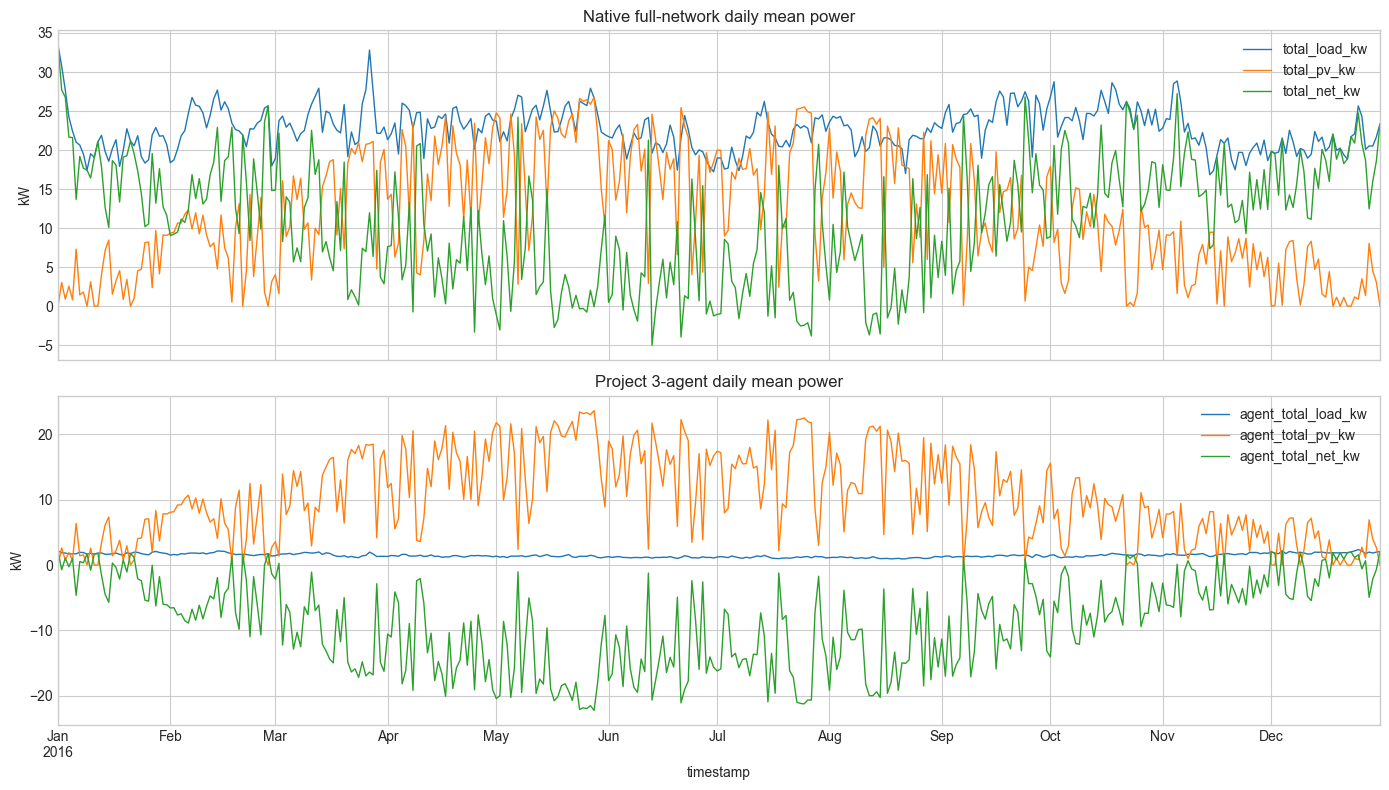

,agent_idx,agent_bus_id,metadata_pv_peak_kw,metadata_ess_power_kw,metadata_ess_capacity_kwh,runtime_battery_capacity_kwh,runtime_battery_max_charge_discharge_kw
0,1,10,46.102448,23.051224,57.628059,5.0,2.5
1,2,6,24.105246,12.052623,30.131557,5.0,2.5
2,3,12,13.860517,6.930258,17.325646,5.0,2.5


In [5]:
static_summary, bus_table, line_table, trafo_table = build_static_tables(raw_net, agent_bus_ids)
display(static_summary)
plot_topology(raw_net, agent_bus_ids, title=f"Topology: {cfg.grid.sb_code}")

display(bus_table[["bus_id", "name", "vn_kv", "type", "category", "has_load", "has_pv", "is_agent_bus", "is_slack"]])
display(line_table[["line_id", "from_bus", "to_bus", "length_km", "std_type", "max_i_ka", "max_loading_percent", "approx_thermal_capacity_kva"]])
display(trafo_table[["trafo_id", "hv_bus", "lv_bus", "std_type", "rated_kva", "vn_hv_kv", "vn_lv_kv", "vk_percent", "tap_side", "tap_min", "tap_max", "tap_step_percent", "max_loading_percent"]])

native_extrema_df = pd.DataFrame(
    [
        extrema_summary(native_year_df, "total_load_kw", "Native full-network total load (kW)"),
        extrema_summary(native_year_df, "total_pv_kw", "Native full-network total PV (kW)"),
        extrema_summary(native_year_df, "total_net_kw", "Native full-network total net load (kW)"),
    ]
)
project_extrema_df = pd.DataFrame(
    [
        extrema_summary(project_year_df, "agent_total_load_kw", "Project 3-agent total load (kW)"),
        extrema_summary(project_year_df, "agent_total_pv_kw", "Project 3-agent total PV (kW)"),
        extrema_summary(project_year_df, "agent_total_net_kw", "Project 3-agent total net load (kW)"),
    ]
)
display(native_extrema_df)
display(project_extrema_df)

native_load_peak_table = pd.DataFrame(
    [
        {
            "bus_id": bus,
            "peak_load_kw": float(native_year_df[f"load_bus_{bus}"].max()),
            "peak_time": native_year_df.loc[native_year_df[f"load_bus_{bus}"].idxmax(), "timestamp"],
        }
        for bus in native_load_buses
    ]
).sort_values("peak_load_kw", ascending=False)
native_pv_peak_table = pd.DataFrame(
    [
        {
            "bus_id": bus,
            "peak_pv_kw": float(native_year_df[f"pv_bus_{bus}"].max()),
            "peak_time": native_year_df.loc[native_year_df[f"pv_bus_{bus}"].idxmax(), "timestamp"],
        }
        for bus in native_pv_buses
    ]
).sort_values("peak_pv_kw", ascending=False)
display(native_load_peak_table)
display(native_pv_peak_table)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
native_daily = native_year_df.set_index("timestamp")[["total_load_kw", "total_pv_kw", "total_net_kw"]].resample("D").mean()
project_daily = project_year_df.set_index("timestamp")[["agent_total_load_kw", "agent_total_pv_kw", "agent_total_net_kw"]].resample("D").mean()
native_daily.plot(ax=axes[0], linewidth=1.0)
axes[0].set_title("Native full-network daily mean power")
axes[0].set_ylabel("kW")
project_daily.plot(ax=axes[1], linewidth=1.0)
axes[1].set_title("Project 3-agent daily mean power")
axes[1].set_ylabel("kW")
plt.tight_layout()
plt.show()

agent_metadata_table = pd.DataFrame(
    {
        "agent_idx": list(range(1, len(agent_bus_ids) + 1)),
        "agent_bus_id": agent_bus_ids,
        "metadata_pv_peak_kw": metadata.get("pv_peak_kw", []),
        "metadata_ess_power_kw": metadata.get("ess_power_kw", []),
        "metadata_ess_capacity_kwh": metadata.get("ess_capacity_kwh", []),
        "runtime_battery_capacity_kwh": [float(cfg.env.battery_capacity)] * len(agent_bus_ids),
        "runtime_battery_max_charge_discharge_kw": [float(cfg.env.max_charge_rate)] * len(agent_bus_ids),
    }
)
display(agent_metadata_table)


,season,date,day_load_mwh,day_pv_mwh,day_mean_net_kw,day_peak_net_kw,day_min_net_kw,median_distance
0,Winter,2016-01-29,0.522647,0.099743,17.620995,33.906849,3.267021,0.000000
1,Spring,2016-04-15,0.584814,0.435907,6.204470,41.061302,-43.719070,0.076400
2,Summer,2016-06-15,0.495763,0.424443,2.971687,35.857792,-40.821003,0.117418
3,Autumn,2016-09-26,0.458411,0.109651,14.531680,32.235741,-3.348305,0.000000


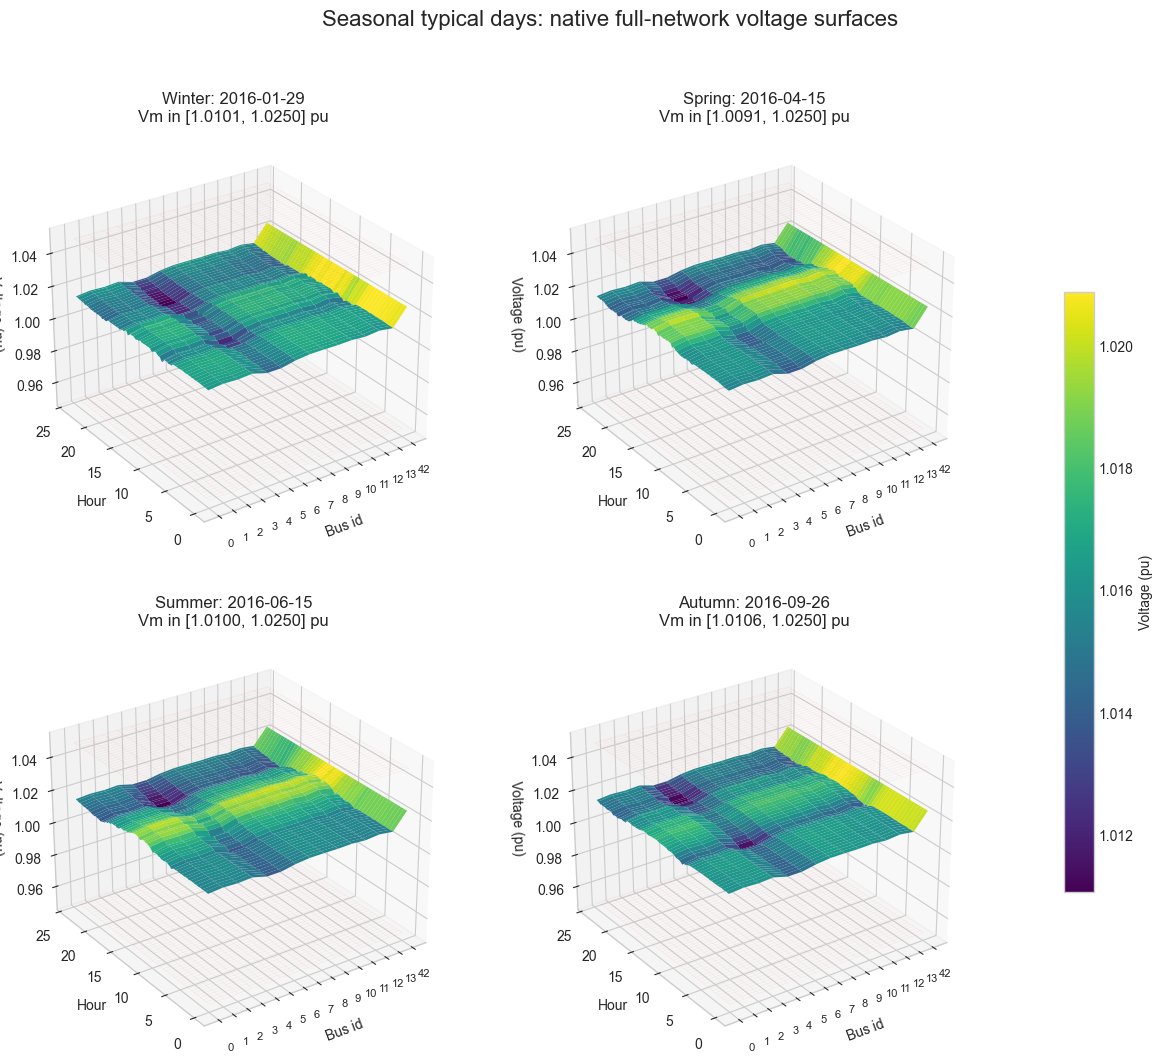

In [6]:
daily_stats, typical_days = select_typical_days(native_year_df)
display(typical_days)

seasonal_day_results = {
    row["season"]: simulate_native_day(row["date"])
    for _, row in typical_days.iterrows()
}
plot_seasonal_voltage_surfaces(
    seasonal_day_results,
    title_prefix="Seasonal typical days: native full-network voltage surfaces",
)


In [7]:
native_key_rows = {
    "native_max_total_load": native_year_df.loc[native_year_df["total_load_kw"].idxmax()],
    "native_max_total_pv": native_year_df.loc[native_year_df["total_pv_kw"].idxmax()],
    "native_max_total_net_load": native_year_df.loc[native_year_df["total_net_kw"].idxmax()],
    "native_max_total_net_export": native_year_df.loc[native_year_df["total_net_kw"].idxmin()],
}
native_snapshot_states = [run_native_snapshot(row, label) for label, row in native_key_rows.items()]
native_snapshot_summary = pd.DataFrame([summarize_snapshot(state) for state in native_snapshot_states])
display(native_snapshot_summary)

project_peak_import_row = project_year_df.loc[project_year_df["agent_total_net_kw"].idxmax()]
project_peak_export_row = project_year_df.loc[project_year_df["agent_total_net_kw"].idxmin()]
battery_limit = float(cfg.env.max_charge_rate)
agent_scenarios = [
    ("project_env_peak_import_no_batt", project_peak_import_row, np.zeros(len(agent_bus_ids), dtype=float)),
    ("project_env_peak_import_max_charge", project_peak_import_row, np.full(len(agent_bus_ids), battery_limit, dtype=float)),
    ("project_env_peak_import_max_discharge", project_peak_import_row, np.full(len(agent_bus_ids), -battery_limit, dtype=float)),
    ("project_env_peak_export_no_batt", project_peak_export_row, np.zeros(len(agent_bus_ids), dtype=float)),
    ("project_env_peak_export_max_charge", project_peak_export_row, np.full(len(agent_bus_ids), battery_limit, dtype=float)),
    ("project_env_peak_export_max_discharge", project_peak_export_row, np.full(len(agent_bus_ids), -battery_limit, dtype=float)),
]
project_states = [run_project_env_snapshot(row, batt_kw=batt_kw, label=label) for label, row, batt_kw in agent_scenarios]
project_summary_rows = []
for state in project_states:
    summary = summarize_snapshot(state)
    summary["agent_load_kw"] = np.round(state["agent_load_kw"], 4).tolist()
    summary["agent_pv_kw"] = np.round(state["agent_pv_kw"], 4).tolist()
    summary["agent_base_net_load_kw"] = np.round(state["agent_base_net_load_kw"], 4).tolist()
    summary["agent_batt_kw"] = np.round(state["agent_batt_kw"], 4).tolist()
    summary["agent_injection_map_kw"] = {int(k): round(float(v), 4) for k, v in state["agent_bus_injection_map_kw"].items()}
    project_summary_rows.append(summary)
project_snapshot_summary = pd.DataFrame(project_summary_rows)
display(project_snapshot_summary)

most_stressed_state = max(project_states, key=lambda state: float(state["line_df"]["loading_percent"].max()))
display(pd.Series({
    "most_stressed_project_label": most_stressed_state["label"],
    "timestamp": most_stressed_state["timestamp"],
    "max_line_loading_pct": float(most_stressed_state["line_df"]["loading_percent"].max()),
    "max_trafo_loading_pct": float(most_stressed_state["trafo_df"]["loading_percent"].max()) if len(most_stressed_state["trafo_df"]) else np.nan,
    "vm_min": float(most_stressed_state["bus_df"]["vm_pu"].min()),
    "vm_max": float(most_stressed_state["bus_df"]["vm_pu"].max()),
} ))
display(most_stressed_state["bus_df"])
display(most_stressed_state["line_df"].sort_values("loading_percent", ascending=False))
display(most_stressed_state["trafo_df"].sort_values("loading_percent", ascending=False))


,label,timestamp,vm_min,vm_min_bus,vm_max,vm_max_bus,max_line_loading_pct,max_line_id,max_trafo_loading_pct,max_trafo_id,slack_p_mw
0,native_max_total_load,2016-01-01 12:30:00,1.002696,4,1.025,42,21.154428,2,50.404666,0,0.075702
1,native_max_total_pv,2016-05-26 13:00:00,1.020309,4,1.025,42,25.890403,6,41.043241,0,-0.058384
2,native_max_total_net_load,2016-01-01 12:30:00,1.002696,4,1.025,42,21.154428,2,50.404666,0,0.075702
3,native_max_total_net_export,2016-07-27 13:15:00,1.022815,4,1.025,42,25.166090,6,46.520756,0,-0.068343


,label,timestamp,vm_min,vm_min_bus,vm_max,vm_max_bus,max_line_loading_pct,max_line_id,max_trafo_loading_pct,max_trafo_id,slack_p_mw,agent_load_kw,agent_pv_kw,agent_base_net_load_kw,agent_batt_kw,agent_injection_map_kw
0,project_env_peak_import_no_batt,2016-12-24 12:00:00,1.004248,4,1.025,42,20.758284,2,41.551645,0,0.059776,"[1.5084, 2.2606, 0.8683]","[0.0, 0.0, 0.0]","[1.5084, 2.2606, 0.8683]","[0.0, 0.0, 0.0]","{10: -1.5084, 6: -2.2606, 12: -0.8683}"
1,project_env_peak_import_max_charge,2016-12-24 12:00:00,1.003370,4,1.025,42,22.010763,2,45.731195,0,0.067377,"[1.5084, 2.2606, 0.8683]","[0.0, 0.0, 0.0]","[1.5084, 2.2606, 0.8683]","[2.5, 2.5, 2.5]","{10: -4.0084, 6: -4.7606, 12: -3.3683}"
2,project_env_peak_import_max_discharge,2016-12-24 12:00:00,1.005122,4,1.025,42,19.519887,2,37.495282,0,0.052187,"[1.5084, 2.2606, 0.8683]","[0.0, 0.0, 0.0]","[1.5084, 2.2606, 0.8683]","[-2.5, -2.5, -2.5]","{10: 0.9916, 6: 0.2394, 12: 1.6317}"
3,project_env_peak_export_no_batt,2016-05-26 13:00:00,1.013638,4,1.025,42,25.141726,6,25.252983,0,-0.025737,"[0.0787, 1.3291, 0.0896]","[45.5078, 23.2232, 13.3533]","[-45.4291, -21.8941, -13.2637]","[0.0, 0.0, 0.0]","{10: 45.4291, 6: 21.8941, 12: 13.2637}"
4,project_env_peak_export_max_charge,2016-05-26 13:00:00,1.012810,4,1.025,42,23.866363,6,22.606396,0,-0.018272,"[0.0787, 1.3291, 0.0896]","[45.5078, 23.2232, 13.3533]","[-45.4291, -21.8941, -13.2637]","[2.5, 2.5, 2.5]","{10: 42.9291, 6: 19.3941, 12: 10.7637}"
5,project_env_peak_export_max_discharge,2016-05-26 13:00:00,1.014461,4,1.025,42,26.417044,6,28.392598,0,-0.033191,"[0.0787, 1.3291, 0.0896]","[45.5078, 23.2232, 13.3533]","[-45.4291, -21.8941, -13.2637]","[-2.5, -2.5, -2.5]","{10: 47.9291, 6: 24.3941, 12: 15.7637}"


most_stressed_project_label    project_env_peak_export_max_discharge
timestamp                                        2016-05-26 13:00:00
max_line_loading_pct                                       26.417044
max_trafo_loading_pct                                      28.392598
vm_min                                                      1.014461
vm_max                                                         1.025
dtype: object

,bus_id,is_agent_bus,load_kw,sgen_kw,specified_net_injection_kw,slack_ext_grid_kw,total_bus_injection_kw,vm_pu
0,0,False,14.0,0.000000,-14.000000,0.0000,-14.000000,1.018036
1,1,False,4.0,0.000000,-4.000000,0.0000,-4.000000,1.020879
2,2,False,8.0,0.000000,-8.000000,0.0000,-8.000000,1.020539
3,3,False,0.0,0.000000,0.000000,0.0000,0.000000,1.020751
4,4,False,14.0,0.000000,-14.000000,0.0000,-14.000000,1.014461
5,5,False,3.0,0.000000,-3.000000,0.0000,-3.000000,1.014515
6,6,True,0.0,24.394146,24.394146,0.0000,24.394146,1.019779
7,7,False,3.0,19.000000,16.000000,0.0000,16.000000,1.021057
8,8,False,4.0,0.000000,-4.000000,0.0000,-4.000000,1.021124
9,9,False,6.0,0.000000,-6.000000,0.0000,-6.000000,1.021191


,line_id,from_bus,to_bus,length_km,std_type,max_i_ka,max_loading_percent,loading_percent,p_from_mw
6,6,3,7,0.005141,NAYY 4x150SE 0.6/1kV,0.27,100.0,26.417044,-0.049877
7,7,11,6,0.002147,NAYY 4x150SE 0.6/1kV,0.27,100.0,19.219246,-0.034096
4,4,7,10,0.016089,NAYY 4x150SE 0.6/1kV,0.27,100.0,18.052311,-0.033893
1,1,13,11,0.053576,NAYY 4x150SE 0.6/1kV,0.27,100.0,12.454859,-0.022058
8,8,5,13,0.137215,NAYY 4x150SE 0.6/1kV,0.27,100.0,9.632579,-0.017001
2,2,6,3,0.049814,NAYY 4x150SE 0.6/1kV,0.27,100.0,9.213964,-0.009705
11,11,12,8,0.046015,NAYY 4x150SE 0.6/1kV,0.27,100.0,8.255779,0.015764
12,12,4,5,0.002583,NAYY 4x150SE 0.6/1kV,0.27,100.0,7.932746,-0.014000
9,9,3,0,0.132499,NAYY 4x150SE 0.6/1kV,0.27,100.0,7.904895,0.014037
5,5,10,9,0.024766,NAYY 4x150SE 0.6/1kV,0.27,100.0,7.882882,0.014012


,trafo_id,hv_bus,lv_bus,std_type,sn_mva,vn_hv_kv,vn_lv_kv,max_loading_percent,loading_percent,p_hv_mw
0,0,42,3,0.16 MVA 20/0.4 kV DOTE 160/20 SGB,0.16,20.0,0.4,100.0,28.392598,-0.033191


## Reading Guide

- The static tables tell you the equipment nameplate ratings: transformer `sn_mva`, line `max_i_ka`, and the environment limits (`0.95-1.05 pu`, `100%` line loading).
- The native full-network yearly tables come from the full SimBench profile expansion for all native load/PV buses.
- The project 3-agent yearly tables come from `data/simbench_2016_full.csv`, which only contains the selected agent buses rather than the whole native network.
- The project-env snapshot section reflects the current environment approximation: non-agent buses stay at the raw SimBench snapshot values, while agent buses are overwritten by the agent-side net injection plus battery action.
- The seasonal 3D voltage surfaces are native-network runs, chosen from one representative day in each season using the daily mean net-load median criterion.
